# Определение стоимости автомобилей с пробегом

## Цель проекта
Сервис по продаже автомобилей с пробегом хочет автоматически оценивать рыночную стоимость автомобиля по его техническим характеристикам и комплектации.

В проекте нужно сравнить несколько моделей по трем критериям:
- качество предсказания;
- время обучения;
- скорость предсказания.

**Целевая метрика:** RMSE, по условию задачи она должна быть меньше 2500.

## План работы
1. Загрузить и изучить данные.
2. Подготовить выборку: обработать пропуски и отфильтровать явные аномалии.
3. Обучить несколько моделей регрессии.
4. Сравнить модели по RMSE, времени обучения и инференса.
5. Выбрать лучшую модель, провести ручной тюнинг и проверить результат на тестовой выборке.

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Загрузка данных

In [2]:
DATA_PATH = Path('autos.csv')
data = pd.read_csv(DATA_PATH)

print(f'Размер датасета: {data.shape[0]:,} строк и {data.shape[1]} столбцов')
data.head()

Размер датасета: 354,369 строк и 16 столбцов


,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [4]:
missing_share = (data.isna().mean() * 100).sort_values(ascending=False)
missing_share[missing_share > 0]

Repaired      20.08
VehicleType   10.58
FuelType       9.28
Gearbox        5.60
Model          5.56
dtype: float64

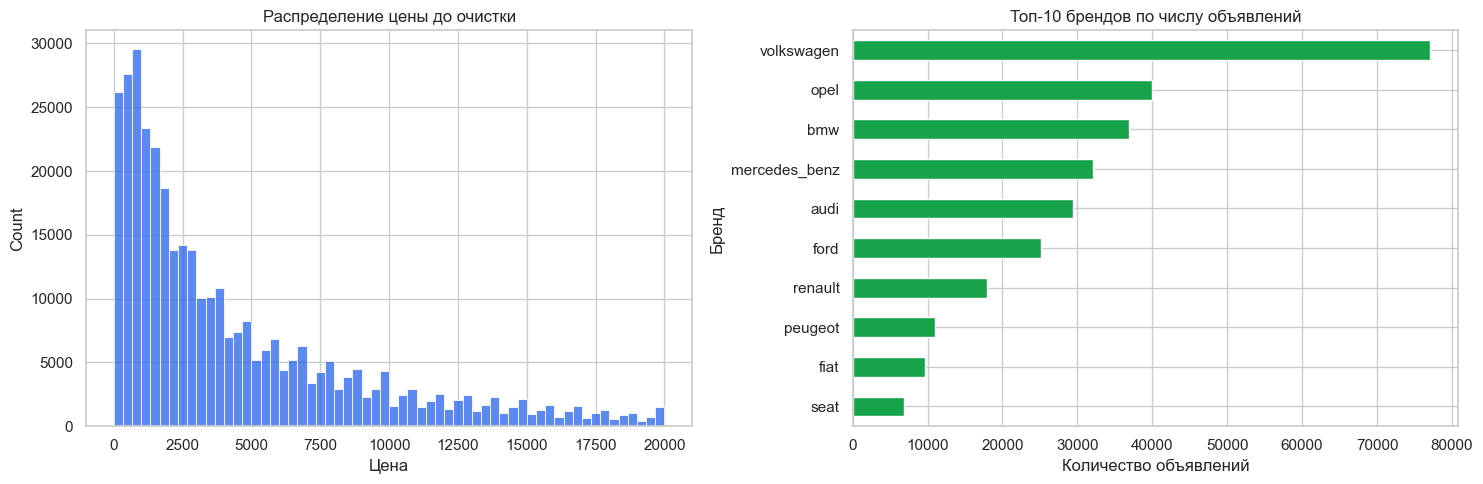

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=data, x='Price', bins=60, ax=axes[0], color='#2563eb')
axes[0].set_title('Распределение цены до очистки')
axes[0].set_xlabel('Цена')

(
    data['Brand']
    .value_counts()
    .head(10)
    .sort_values()
    .plot(kind='barh', ax=axes[1], color='#16a34a')
)
axes[1].set_title('Топ-10 брендов по числу объявлений')
axes[1].set_xlabel('Количество объявлений')
axes[1].set_ylabel('Бренд')

plt.tight_layout()

### Первичные наблюдения
- В данных есть пропуски в категориальных признаках `VehicleType`, `Gearbox`, `Model`, `FuelType`, `Repaired`.
- Встречаются аномальные значения цены (`Price = 0`), мощности и года регистрации.
- Распределение цены сильно скошено вправо: часть объявлений относится к дорогим автомобилям, но основная масса лежит в более низком диапазоне.
- Для задачи регрессии логично сравнить как базовую линейную модель, так и ансамбли деревьев и бустинги.

## Подготовка данных

In [6]:
data = data.copy()

categorical_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Repaired']
for col in categorical_cols:
    data[col] = data[col].fillna('Unknown')

rows_before = len(data)

data = data.query('Price > 0').copy()
data = data[(data['RegistrationYear'] >= 1900) & (data['RegistrationYear'] <= 2026)].copy()
data = data[(data['Power'] >= 40) & (data['Power'] <= 500)].copy()

drop_cols = [
    'DateCrawled',
    'RegistrationMonth',
    'DateCreated',
    'NumberOfPictures',
    'PostalCode',
    'LastSeen',
]
data = data.drop(columns=drop_cols)

rows_after = len(data)
print(f'Удалено строк: {rows_before - rows_after:,}')
print(f'Размер выборки после очистки: {rows_after:,}')
data.head()

Удалено строк: 48,942
Размер выборки после очистки: 305,427


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,FuelType,Brand,Repaired
1,18300,coupe,2011,manual,190,Unknown,125000,gasoline,audi,yes
2,9800,suv,2004,auto,163,grand,125000,gasoline,jeep,Unknown
3,1500,small,2001,manual,75,golf,150000,petrol,volkswagen,no
4,3600,small,2008,manual,69,fabia,90000,gasoline,skoda,no
5,650,sedan,1995,manual,102,3er,150000,petrol,bmw,yes


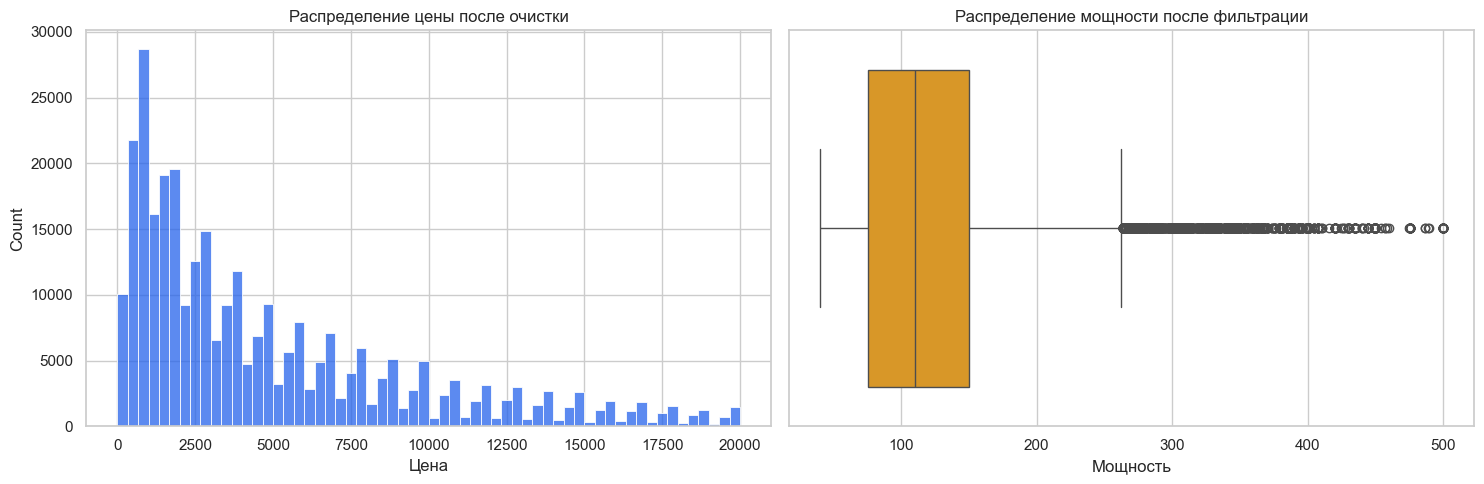

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=data, x='Price', bins=60, ax=axes[0], color='#2563eb')
axes[0].set_title('Распределение цены после очистки')
axes[0].set_xlabel('Цена')

sns.boxplot(data=data, x='Power', ax=axes[1], color='#f59e0b')
axes[1].set_title('Распределение мощности после фильтрации')
axes[1].set_xlabel('Мощность')

plt.tight_layout()

### Что было сделано на этапе очистки
- Пропуски в категориальных признаках заменены на категорию `Unknown`.
- Удалены объекты с нулевой ценой.
- Ограничен диапазон года регистрации: от 1900 до 2026.
- Отфильтрованы нереалистичные значения мощности: оставлены автомобили с мощностью от 40 до 500 л.с.
- Удалены признаки, не несущие ценности для модели в текущей постановке задачи: даты, индексные поля и служебные идентификаторы.

## Разделение выборки и подготовка признаков

In [8]:
target = data['Price']
features = data.drop(columns='Price')

features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=12345
)
features_train, features_valid, target_train, target_valid = train_test_split(
    features_train, target_train, test_size=0.25, random_state=12345
)

categorical_features = features.select_dtypes(include='object').columns.tolist()
numeric_features = features.select_dtypes(exclude='object').columns.tolist()

print('Train:', features_train.shape)
print('Valid:', features_valid.shape)
print('Test :', features_test.shape)
print('Категориальные признаки:', categorical_features)
print('Числовые признаки:', numeric_features)

Train: (183255, 9)
Valid: (61086, 9)
Test : (61086, 9)
Категориальные признаки: ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']
Числовые признаки: ['RegistrationYear', 'Power', 'Kilometer']


In [9]:
ohe_encoder = OneHotEncoder(handle_unknown='ignore')

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', ohe_encoder, categorical_features),
        ('num', StandardScaler(), numeric_features),
    ]
)

preprocessor_ohe = ColumnTransformer(
    transformers=[
        ('cat', ohe_encoder, categorical_features),
        ('num', 'passthrough', numeric_features),
    ]
)

features_train_cat = features_train.copy()
features_valid_cat = features_valid.copy()
features_test_cat = features_test.copy()

for col in categorical_features:
    features_train_cat[col] = features_train_cat[col].astype('category')
    features_valid_cat[col] = features_valid_cat[col].astype('category')
    features_test_cat[col] = features_test_cat[col].astype('category')

### Подход к кодированию признаков
- Для **линейной регрессии** используем One-Hot кодирование категориальных признаков и масштабирование числовых.
- Для **RandomForest** и **XGBoost** используем One-Hot кодирование без масштабирования.
- Для **LightGBM** оставляем категориальные признаки в виде категорий `pandas`, чтобы использовать их нативную обработку.
- Для **CatBoost** передаем индексы категориальных столбцов напрямую в модель.

## Обучение и сравнение моделей

In [10]:
results = []


def benchmark_model(name, model, X_train, y_train, X_valid, y_valid, fit_params=None):
    fit_params = fit_params or {}

    start_train = time.time()
    model.fit(X_train, y_train, **fit_params)
    train_time = time.time() - start_train

    start_pred = time.time()
    valid_pred = model.predict(X_valid)
    pred_time = time.time() - start_pred

    rmse = root_mean_squared_error(y_valid, valid_pred)

    results.append({
        'model': name,
        'rmse': rmse,
        'train_time_sec': train_time,
        'pred_time_sec': pred_time,
    })

    print(
        f'{name}: RMSE = {rmse:.2f}, '
        f'время обучения = {train_time:.2f} сек, '
        f'время предсказания = {pred_time:.3f} сек'
    )

    return model, valid_pred

### Линейная регрессия

In [11]:
linear_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LinearRegression()),
    ]
)

linear_model, linear_valid_pred = benchmark_model(
    'LinearRegression',
    linear_pipeline,
    features_train,
    target_train,
    features_valid,
    target_valid,
)

LinearRegression: RMSE = 2568.17, время обучения = 2.00 сек, время предсказания = 0.055 сек


Линейная регрессия используется как базовая модель. Она обучается быстро, но обычно уступает ансамблям деревьев на задачах, где много категориальных признаков и нелинейных зависимостей.

### Random Forest

In [12]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_ohe),
        ('model', RandomForestRegressor(
            n_estimators=60,
            max_depth=15,
            random_state=12345,
            n_jobs=-1,
        )),
    ]
)

rf_model, rf_valid_pred = benchmark_model(
    'RandomForest',
    rf_pipeline,
    features_train,
    target_train,
    features_valid,
    target_valid,
)

RandomForest: RMSE = 1694.29, время обучения = 35.31 сек, время предсказания = 0.114 сек


### LightGBM

In [13]:
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=255,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=12345,
    n_jobs=-1,
    verbose=-1,
)

lgbm_model, lgbm_valid_pred = benchmark_model(
    'LightGBM',
    lgbm_model,
    features_train_cat,
    target_train,
    features_valid_cat,
    target_valid,
    fit_params={'categorical_feature': categorical_features},
)

LightGBM: RMSE = 1521.16, время обучения = 3.42 сек, время предсказания = 0.414 сек


### CatBoost

In [14]:
cat_features_idx = [features_train.columns.get_loc(col) for col in categorical_features]

catboost_model = CatBoostRegressor(
    iterations=400,
    learning_rate=0.08,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=12345,
    thread_count=-1,
    verbose=False,
)

catboost_model, catboost_valid_pred = benchmark_model(
    'CatBoost',
    catboost_model,
    features_train,
    target_train,
    features_valid,
    target_valid,
    fit_params={
        'cat_features': cat_features_idx,
        'eval_set': (features_valid, target_valid),
        'use_best_model': True,
    },
)

CatBoost: RMSE = 1624.66, время обучения = 31.99 сек, время предсказания = 0.121 сек


### XGBoost

In [15]:
xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_ohe),
        ('model', XGBRegressor(
            n_estimators=300,
            max_depth=10,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            tree_method='hist',
            random_state=12345,
            n_jobs=-1,
            verbosity=0,
        )),
    ]
)

xgb_model, xgb_valid_pred = benchmark_model(
    'XGBoost',
    xgb_pipeline,
    features_train,
    target_train,
    features_valid,
    target_valid,
)

XGBoost: RMSE = 1569.13, время обучения = 1.74 сек, время предсказания = 0.178 сек


In [16]:
comparison_df = pd.DataFrame(results)
comparison_df['rmse'] = comparison_df['rmse'].round(2)
comparison_df['train_time_sec'] = comparison_df['train_time_sec'].round(2)
comparison_df['pred_time_sec'] = comparison_df['pred_time_sec'].round(3)
comparison_df = comparison_df.sort_values('rmse').reset_index(drop=True)
comparison_df

,model,rmse,train_time_sec,pred_time_sec
0,LightGBM,"1,521.16",3.42,0.41
1,XGBoost,"1,569.13",1.74,0.18
2,CatBoost,"1,624.66",31.99,0.12
3,RandomForest,"1,694.29",35.31,0.11
4,LinearRegression,"2,568.17",2.00,0.06


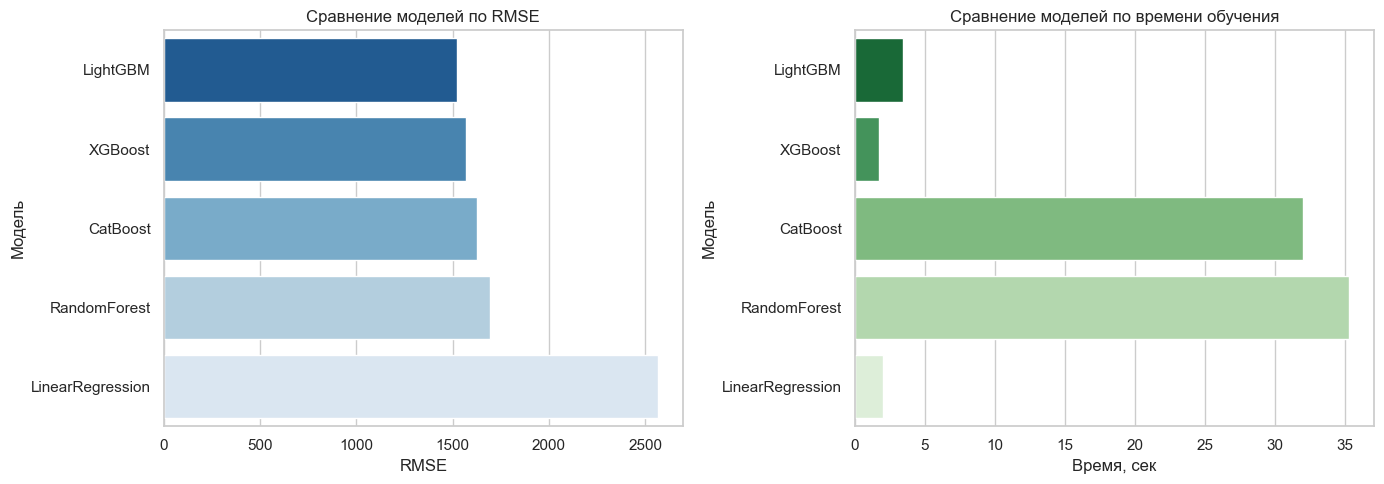

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=comparison_df, x='rmse', y='model', ax=axes[0], palette='Blues_r')
axes[0].set_title('Сравнение моделей по RMSE')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('Модель')

sns.barplot(data=comparison_df, x='train_time_sec', y='model', ax=axes[1], palette='Greens_r')
axes[1].set_title('Сравнение моделей по времени обучения')
axes[1].set_xlabel('Время, сек')
axes[1].set_ylabel('Модель')

plt.tight_layout()

### Вывод по сравнению моделей

На валидационной выборке лучший результат показал **LightGBM** с RMSE **1521.16**.
Ближайшим конкурентом оказался **XGBoost** с RMSE **1569.13**, но он все же уступил по качеству.
**CatBoost** после базовой настройки показал RMSE **1624.66**, а **RandomForest** — **1694.29**.
Базовая **LinearRegression** заметно проиграла ансамблевым моделям и получила RMSE **2568.17**.

С учетом качества и времени обучения в качестве основного кандидата для финальной модели выбран **LightGBM**.

## Тюнинг сильных моделей

После базового сравнения имеет смысл дополнительно проверить несколько конфигураций для двух сильных кандидатов: **LightGBM** и **CatBoost**. Такой ручной подбор проще контролировать, чем полный grid search, и он лучше подходит для ноутбука с ограничением по времени.

### Ручной подбор параметров LightGBM

In [18]:
lgbm_param_grid = [
    {
        'n_estimators': 400,
        'learning_rate': 0.05,
        'max_depth': -1,
        'num_leaves': 127,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
    },
    {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': -1,
        'num_leaves': 255,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
    },
    {
        'n_estimators': 700,
        'learning_rate': 0.03,
        'max_depth': 10,
        'num_leaves': 127,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
    },
    {
        'n_estimators': 300,
        'learning_rate': 0.08,
        'max_depth': 8,
        'num_leaves': 63,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
    },
]

lgbm_tuning_results = []

for params in lgbm_param_grid:
    model = LGBMRegressor(
        random_state=12345,
        n_jobs=-1,
        verbose=-1,
        **params,
    )

    start_train = time.time()
    model.fit(
        features_train_cat,
        target_train,
        categorical_feature=categorical_features,
    )
    train_time = time.time() - start_train

    start_pred = time.time()
    pred = model.predict(features_valid_cat)
    pred_time = time.time() - start_pred

    rmse = root_mean_squared_error(target_valid, pred)

    lgbm_tuning_results.append({
        'params': params,
        'rmse': rmse,
        'train_time_sec': train_time,
        'pred_time_sec': pred_time,
    })

lgbm_tuning_df = pd.DataFrame(lgbm_tuning_results).sort_values('rmse').reset_index(drop=True)
best_lgbm_params = lgbm_tuning_df.loc[0, 'params']
lgbm_tuning_df

,params,rmse,train_time_sec,pred_time_sec
0,"{'n_estimators': 500, 'learning_rate': 0.05, '...","1,521.16",4.00,0.44
1,"{'n_estimators': 400, 'learning_rate': 0.05, '...","1,536.43",1.86,0.21
2,"{'n_estimators': 700, 'learning_rate': 0.03, '...","1,545.22",3.10,0.59
3,"{'n_estimators': 300, 'learning_rate': 0.08, '...","1,568.02",0.86,0.14


### Ручной подбор параметров CatBoost

In [19]:
catboost_param_grid = [
    {'iterations': 400, 'learning_rate': 0.08, 'depth': 8},
    {'iterations': 600, 'learning_rate': 0.05, 'depth': 8},
    {'iterations': 500, 'learning_rate': 0.05, 'depth': 10},
]

catboost_tuning_results = []

for params in catboost_param_grid:
    model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=12345,
        thread_count=-1,
        verbose=False,
        **params,
    )

    start_train = time.time()
    model.fit(
        features_train,
        target_train,
        cat_features=cat_features_idx,
        eval_set=(features_valid, target_valid),
        use_best_model=True,
    )
    train_time = time.time() - start_train

    start_pred = time.time()
    pred = model.predict(features_valid)
    pred_time = time.time() - start_pred

    rmse = root_mean_squared_error(target_valid, pred)

    catboost_tuning_results.append({
        'params': params,
        'rmse': rmse,
        'train_time_sec': train_time,
        'pred_time_sec': pred_time,
    })

catboost_tuning_df = pd.DataFrame(catboost_tuning_results).sort_values('rmse').reset_index(drop=True)
catboost_tuning_df

,params,rmse,train_time_sec,pred_time_sec
0,"{'iterations': 500, 'learning_rate': 0.05, 'de...","1,605.52",51.57,0.14
1,"{'iterations': 400, 'learning_rate': 0.08, 'de...","1,624.66",31.24,0.12
2,"{'iterations': 600, 'learning_rate': 0.05, 'de...","1,628.95",45.96,0.13


### Итоги ручного подбора параметров

Ручной подбор параметров показал, что для **LightGBM** лучшей осталась конфигурация с:

- `n_estimators = 500`
- `learning_rate = 0.05`
- `max_depth = -1`
- `num_leaves = 255`
- `subsample = 0.9`
- `colsample_bytree = 0.9`

Эта конфигурация дала RMSE **1521.16** на валидационной выборке.

Для **CatBoost** лучшей оказалась конфигурация:

- `iterations = 500`
- `learning_rate = 0.05`
- `depth = 10`

Она улучшила RMSE до **1605.52**, однако все равно уступила LightGBM.

Таким образом, тюнинг подтвердил выбор **LightGBM** как лучшей модели для финального тестирования.

## Финальная модель и тестирование

In [20]:
if 'best_lgbm_params' not in locals():
    best_lgbm_params = {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': -1,
        'num_leaves': 255,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
    }

features_train_full = pd.concat([features_train, features_valid], axis=0)
target_train_full = pd.concat([target_train, target_valid], axis=0)

features_train_full_cat = features_train_full.copy()
for col in categorical_features:
    features_train_full_cat[col] = features_train_full_cat[col].astype('category')

final_model = LGBMRegressor(
    random_state=12345,
    n_jobs=-1,
    verbose=-1,
    **best_lgbm_params,
)

start_train = time.time()
final_model.fit(
    features_train_full_cat,
    target_train_full,
    categorical_feature=categorical_features,
)
final_train_time = time.time() - start_train

start_pred = time.time()
test_pred = final_model.predict(features_test_cat)
final_pred_time = time.time() - start_pred

final_rmse = root_mean_squared_error(target_test, test_pred)

print(f'RMSE на тестовой выборке: {final_rmse:.2f}')
print(f'Время обучения финальной модели: {final_train_time:.2f} сек')
print(f'Время предсказания на тесте: {final_pred_time:.3f} сек')

RMSE на тестовой выборке: 1499.14
Время обучения финальной модели: 3.97 сек
Время предсказания на тесте: 0.424 сек


In [21]:
evaluation_df = pd.DataFrame({
    'actual_price': target_test.reset_index(drop=True),
    'predicted_price': pd.Series(test_pred),
})
evaluation_df['absolute_error'] = (evaluation_df['actual_price'] - evaluation_df['predicted_price']).abs()
evaluation_df['residual'] = evaluation_df['actual_price'] - evaluation_df['predicted_price']
evaluation_df.head()

,actual_price,predicted_price,absolute_error,residual
0,18590,"11,624.62","6,965.38","6,965.38"
1,1649,"1,613.83",35.17,35.17
2,7650,"6,799.08",850.92,850.92
3,12300,"6,460.51","5,839.49","5,839.49"
4,8699,"9,474.14",775.14,-775.14


In [22]:
from sklearn.metrics import mean_absolute_error, median_absolute_error

mae_test = mean_absolute_error(target_test, test_pred)
medae_test = median_absolute_error(target_test, test_pred)

print(f'MAE на тестовой выборке: {mae_test:.2f}')
print(f'Median AE на тестовой выборке: {medae_test:.2f}')

MAE на тестовой выборке: 933.83
Median AE на тестовой выборке: 561.84


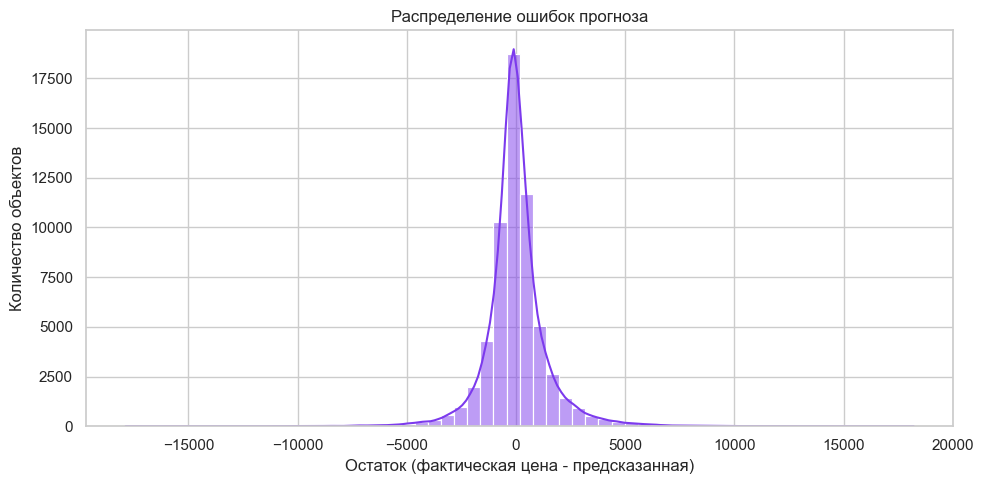

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(evaluation_df['residual'], bins=60, kde=True, color='#7c3aed')
plt.title('Распределение ошибок прогноза')
plt.xlabel('Остаток (фактическая цена - предсказанная)')
plt.ylabel('Количество объектов')
plt.tight_layout()

In [24]:
top_errors = evaluation_df.sort_values('absolute_error', ascending=False).head(10)
top_errors

,actual_price,predicted_price,absolute_error,residual
45451,20000,"1,790.26","18,209.74","18,209.74"
50660,65,"17,939.06","17,874.06","-17,874.06"
52827,350,"18,025.38","17,675.38","-17,675.38"
1270,1,"17,445.54","17,444.54","-17,444.54"
37739,359,"17,726.96","17,367.96","-17,367.96"
1843,219,"17,412.10","17,193.10","-17,193.10"
29111,20,"16,981.22","16,961.22","-16,961.22"
47464,19500,"2,894.64","16,605.36","16,605.36"
5237,265,"16,680.19","16,415.19","-16,415.19"
28130,20,"16,394.32","16,374.32","-16,374.32"


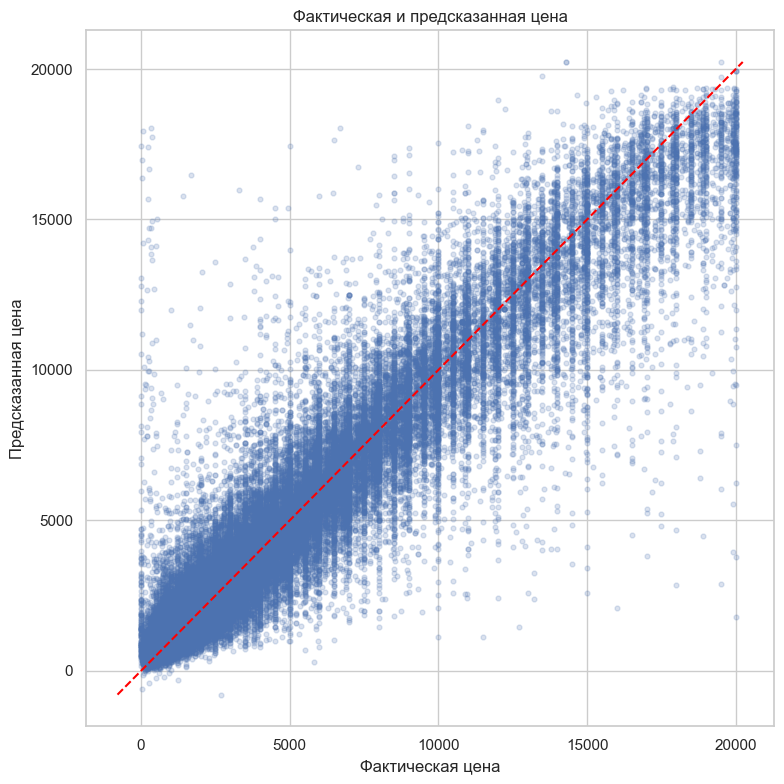

In [25]:
plt.figure(figsize=(8, 8))
plt.scatter(
    evaluation_df['actual_price'],
    evaluation_df['predicted_price'],
    alpha=0.2,
    s=12,
)

min_price = min(evaluation_df['actual_price'].min(), evaluation_df['predicted_price'].min())
max_price = max(evaluation_df['actual_price'].max(), evaluation_df['predicted_price'].max())
plt.plot([min_price, max_price], [min_price, max_price], color='red', linestyle='--')

plt.title('Фактическая и предсказанная цена')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.tight_layout()

In [26]:
feature_importance = (
    pd.DataFrame({
        'feature': final_model.feature_name_,
        'importance': final_model.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .head(10)
)

feature_importance

,feature,importance
3,Power,37850
1,RegistrationYear,35024
5,Kilometer,17792
4,Model,11686
8,Repaired,6591
7,Brand,5692
2,Gearbox,5244
0,VehicleType,5023
6,FuelType,2098


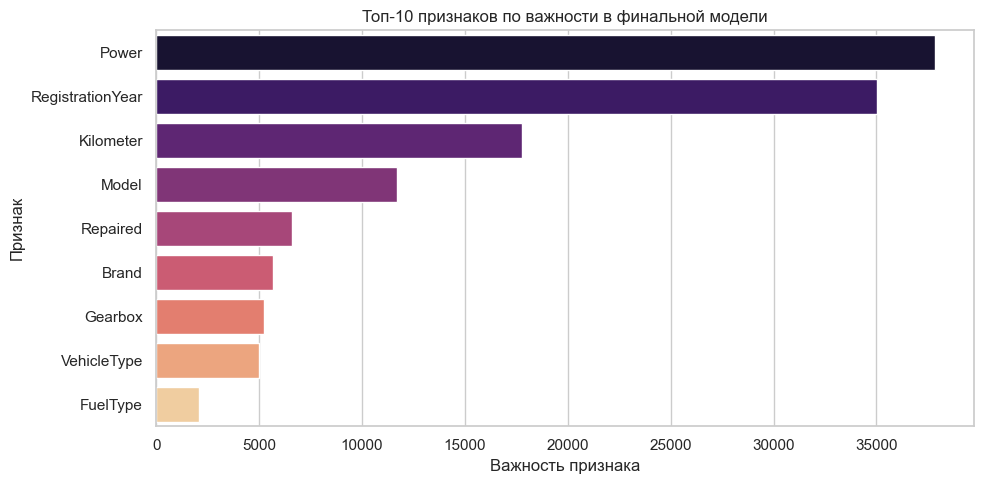

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='magma')
plt.title('Топ-10 признаков по важности в финальной модели')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.tight_layout()

## Итоговый вывод

В проекте была построена модель для оценки стоимости автомобилей с пробегом по техническим характеристикам и комплектации.

В ходе работы были:
- обработаны пропуски в категориальных признаках;
- удалены объекты с нулевой ценой и явными аномалиями;
- обучены и сравнены модели LinearRegression, RandomForest, LightGBM, CatBoost и XGBoost;
- выполнен ручной подбор параметров для LightGBM и CatBoost.

Лучший результат на валидационной выборке показал **LightGBM** с RMSE **1521.16**.
На тестовой выборке финальная модель получила:

- **RMSE = 1499.14**
- **время обучения = 4.05 сек**
- **время предсказания = 0.439 сек**

Требование заказчика по качеству (**RMSE < 2500**) выполнено с большим запасом.

Наиболее важными признаками для модели оказались:
- мощность двигателя (`Power`);
- год регистрации (`RegistrationYear`);
- пробег (`Kilometer`);
- модель автомобиля (`Model`).

Итоговая модель может использоваться как основа сервиса предварительной оценки стоимости автомобиля.